# Reference
- https://github.com/mrzhu-cool/pix2pix-pytorch/blob/master/train.py
- https://github.com/eriklindernoren/PyTorch-GAN
- https://www.kaggle.com/code/ibtesama/gan-in-pytorch-with-fid
- https://github.com/mseitzer/pytorch-fid

In [ ]:
from os import listdir
from os.path import join
import random
import matplotlib.pyplot as plt
%matplotlib inline

import os
import time
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.transforms.functional import to_pil_image
import numpy as np
from torch.nn.functional import adaptive_avg_pool2d

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 데이터 불러오기

In [ ]:
!git clone https://github.com/mrzhu-cool/pix2pix-pytorch # 깃 클론

Cloning into 'pix2pix-pytorch'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 68 (delta 17), reused 14 (delta 14), pack-reused 45
Unpacking objects: 100% (68/68), 84.94 MiB | 9.33 MiB/s, done.


In [ ]:
!mkdir 'data' # 폴더 생성
!mkdir 'data/facades/'
!mkdir 'data/facades/train'
!mkdir 'data/facades/train/a'
!mkdir 'data/facades/train/b'
!mkdir 'data/facades/test'
!mkdir 'data/facades/test/a'
!mkdir 'data/facades/test/b'

# 폴더 생성을 하고 a b 폴더에 데이터 적용
# a 에 원본 데이터
# b 에 스케치 데이터
# b to a 방식으로 데이터가 변환됩니다.

mkdir: cannot create directory ‘data’: File exists
mkdir: cannot create directory ‘data/facades/’: File exists
mkdir: cannot create directory ‘data/facades/train’: File exists
mkdir: cannot create directory ‘data/facades/train/a’: File exists
mkdir: cannot create directory ‘data/facades/train/b’: File exists


In [ ]:
#!unzip /content/pix2pix-pytorch/dataset/facades.zip  -d /content/data; # 데이터 받아와서 압축 풀기

In [ ]:
# Costum dataset 생성

class FacadeDataset(Dataset):
    def __init__(self, path2img, direction='b2a', transform=False):
        super().__init__()
        self.direction = direction
        self.path2a = join(path2img, 'a')
        self.path2b = join(path2img, 'b')
        self.img_filenames = [x for x in listdir(self.path2a)]
        self.transform = transform

    def __getitem__(self, index):
        a = Image.open(join(self.path2a, self.img_filenames[index])).convert('RGB')
        b = Image.open(join(self.path2b, self.img_filenames[index])).convert('RGB')

        if self.transform:
            a = self.transform(a)
            b = self.transform(b)

        if self.direction == 'b2a':
            return b,a
        else:
            return a,b

    def __len__(self):
        return len(self.img_filenames)

In [ ]:
# transforms 정의
transform = transforms.Compose([
                    transforms.ToTensor(),
                    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
                    transforms.Resize((256,256))
])

In [ ]:
# 데이터셋 불러오기
path2img = '/content/data/facades/train'
train_ds = FacadeDataset(path2img, transform=transform)

In [ ]:
# 샘플 이미지 확인하기
a,b = train_ds[2]
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(to_pil_image(0.5*a+0.5))
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(to_pil_image(0.5*b+0.5))
plt.axis('off')

In [ ]:
# 데이터 로더 생성하기
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

# 모델 구축하기

In [ ]:
# UNet
class UNetDown(nn.Module):
    def __init__(self, in_channels, out_channels, normalize=True, dropout=0.0):
        super().__init__()

        layers = [nn.Conv2d(in_channels, out_channels, 4, stride=2, padding=1, bias=False)]

        if normalize:
            layers.append(nn.InstanceNorm2d(out_channels)),

        layers.append(nn.LeakyReLU(0.2))

        if dropout:
            layers.append(nn.Dropout(dropout))

        self.down = nn.Sequential(*layers)

    def forward(self, x):
        x = self.down(x)
        return x

# check
x = torch.randn(16, 3, 256,256, device=device)
model = UNetDown(3,64).to(device)
down_out = model(x)
print(down_out.shape)

torch.Size([16, 64, 128, 128])


In [ ]:
class UNetUp(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()

        layers = [
            nn.ConvTranspose2d(in_channels, out_channels,4,2,1,bias=False),
            nn.InstanceNorm2d(out_channels),
            nn.LeakyReLU()
        ]

        if dropout:
            layers.append(nn.Dropout(dropout))

        self.up = nn.Sequential(*layers)

    def forward(self,x,skip):
        x = self.up(x)
        x = torch.cat((x,skip),1)
        return x

# check
x = torch.randn(16, 128, 64, 64, device=device)
model = UNetUp(128,64).to(device)
out = model(x,down_out)
print(out.shape)

torch.Size([16, 128, 128, 128])


In [ ]:
# generator: 가짜 이미지를 생성합니다.
class GeneratorUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super().__init__()

        self.down1 = UNetDown(in_channels, 64, normalize=False)
        self.down2 = UNetDown(64,128)
        self.down3 = UNetDown(128,256)
        self.down4 = UNetDown(256,512,dropout=0.5)
        self.down5 = UNetDown(512,512,dropout=0.5)
        self.down6 = UNetDown(512,512,dropout=0.5)
        self.down7 = UNetDown(512,512,dropout=0.5)
        self.down8 = UNetDown(512,512,normalize=False,dropout=0.5)

        self.up1 = UNetUp(512,512,dropout=0.5)
        self.up2 = UNetUp(1024,512,dropout=0.5)
        self.up3 = UNetUp(1024,512,dropout=0.5)
        self.up4 = UNetUp(1024,512,dropout=0.5)
        self.up5 = UNetUp(1024,256)
        self.up6 = UNetUp(512,128)
        self.up7 = UNetUp(256,64)
        self.up8 = nn.Sequential(
            nn.ConvTranspose2d(128,3,4,stride=2,padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)
        d8 = self.down8(d7)

        u1 = self.up1(d8,d7)
        u2 = self.up2(u1,d6)
        u3 = self.up3(u2,d5)
        u4 = self.up4(u3,d4)
        u5 = self.up5(u4,d3)
        u6 = self.up6(u5,d2)
        u7 = self.up7(u6,d1)
        u8 = self.up8(u7)

        return u8

# check
x = torch.randn(16,3,256,256,device=device)
model = GeneratorUNet().to(device)
out = model(x)
print(out.shape)

torch.Size([16, 3, 256, 256])


In [ ]:
class Dis_block(nn.Module):
    def __init__(self, in_channels, out_channels, normalize=True):
        super().__init__()

        layers = [nn.Conv2d(in_channels, out_channels, 3, stride=2, padding=1)]
        if normalize:
            layers.append(nn.InstanceNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        x = self.block(x)
        return x

# check
x = torch.randn(16,64,128,128,device=device)
model = Dis_block(64,128).to(device)
out = model(x)
print(out.shape)

torch.Size([16, 128, 64, 64])


In [ ]:
# Discriminator은 patch gan을 사용합니다.
# Patch Gan: 이미지를 16x16의 패치로 분할하여 각 패치가 진짜인지 가짜인지 식별합니다.
# high-frequency에서 정확도가 향상됩니다.

class Discriminator(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()

        self.stage_1 = Dis_block(in_channels*2,64,normalize=False)
        self.stage_2 = Dis_block(64,128)
        self.stage_3 = Dis_block(128,256)
        self.stage_4 = Dis_block(256,512)

        self.patch = nn.Conv2d(512,1,3,padding=1) # 16x16 패치 생성

    def forward(self,a,b):
        x = torch.cat((a,b),1)
        x = self.stage_1(x)
        x = self.stage_2(x)
        x = self.stage_3(x)
        x = self.stage_4(x)
        x = self.patch(x)
        x = torch.sigmoid(x)
        return x
# check
x = torch.randn(16,3,256,256,device=device)
model = Discriminator().to(device)
out = model(x,x)
print(out.shape)

torch.Size([16, 1, 16, 16])


In [ ]:
model_gen = GeneratorUNet().to(device)
model_dis = Discriminator().to(device)

In [ ]:
# 가중치 초기화
def initialize_weights(model):
    class_name = model.__class__.__name__
    if class_name.find('Conv') != -1:
        nn.init.normal_(model.weight.data, 0.0, 0.02)


# 가중치 초기화 적용
model_gen.apply(initialize_weights);
model_dis.apply(initialize_weights);

In [ ]:
''' 오류로 인해 다른 FID 계산법을 사용. 주석처리
def calculate_activation_statistics(images,model,batch_size=128, dims=2048,
                    cuda=False):
    model.eval()
    act=np.empty((len(images), dims))

    if cuda:
        batch=images.cuda()
    else:
        batch=images
    pred = model(batch)[0]

        # If model output is not scalar, apply global spatial average pooling.
        # This happens if you choose a dimensionality not equal 2048.
    if pred.size(2) != 1 or pred.size(3) != 1:
        pred = adaptive_avg_pool2d(pred, output_size=(1, 1))

    act= pred.cpu().data.numpy().reshape(pred.size(0), -1)

    mu = np.mean(act, axis=0)
    sigma = np.cov(act, rowvar=False)
    return mu, sigma

def calculate_frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    """Numpy implementation of the Frechet Distance.
    The Frechet distance between two multivariate Gaussians X_1 ~ N(mu_1, C_1)
    and X_2 ~ N(mu_2, C_2) is
            d^2 = ||mu_1 - mu_2||^2 + Tr(C_1 + C_2 - 2*sqrt(C_1*C_2)).
    """

    mu1 = np.atleast_1d(mu1)
    mu2 = np.atleast_1d(mu2)

    sigma1 = np.atleast_2d(sigma1)
    sigma2 = np.atleast_2d(sigma2)

    assert mu1.shape == mu2.shape, \
        'Training and test mean vectors have different lengths'
    assert sigma1.shape == sigma2.shape, \
        'Training and test covariances have different dimensions'

    diff = mu1 - mu2


    covmean, _ = np.linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if not np.isfinite(covmean).all():
        msg = ('fid calculation produces singular product; '
               'adding %s to diagonal of cov estimates') % eps
        print(msg)
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = np.linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset))


    if np.iscomplexobj(covmean):
        if not np.allclose(np.diagonal(covmean).imag, 0, atol=1e-3):
            m = np.max(np.abs(covmean.imag))
            raise ValueError('Imaginary component {}'.format(m))
        covmean = covmean.real

    tr_covmean = np.trace(covmean)

    return (diff.dot(diff) + np.trace(sigma1) +
            np.trace(sigma2) - 2 * tr_covmean)

def calculate_fretchet(images_real,images_fake,model):
     mu_1,std_1=calculate_activation_statistics(images_real,model,cuda=True)
     mu_2,std_2=calculate_activation_statistics(images_fake,model,cuda=True)

     """get fretched distance"""
     fid_value = calculate_frechet_distance(mu_1, std_1, mu_2, std_2)
     return fid_value
'''

# 학습을 위한 파라미터들

In [ ]:
# 손실함수
loss_func_gan = nn.BCELoss()
loss_func_pix = nn.L1Loss()

# loss_func_pix 가중치
lambda_pixel = 100

# patch 수
patch = (1,256//2**4,256//2**4)

# 최적화 파라미터
from torch import optim
lr = 2e-4
beta1 = 0.5
beta2 = 0.999

batch_count = 0

# 반복 횟수
num_epochs = 400

# 시간을 계산하기 위한 부분
start_time = time.time()

opt_dis = optim.Adam(model_dis.parameters(),lr=lr,betas=(beta1,beta2))
opt_gen = optim.Adam(model_gen.parameters(),lr=lr,betas=(beta1,beta2))

# **학습**

In [ ]:
# 학습
model_gen.train()
model_dis.train()

loss_hist = {'gen':[],
             'dis':[]}

for epoch in range(num_epochs):
    for a, b in train_dl:
        ba_si = a.size(0)

        # real image
        real_a = a.to(device)
        real_b = b.to(device)

        # patch label
        real_label = torch.ones(ba_si, *patch, requires_grad=False).to(device)
        fake_label = torch.zeros(ba_si, *patch, requires_grad=False).to(device)

        # generator
        model_gen.zero_grad()

        fake_b = model_gen(real_a) # 가짜 이미지 생성
        out_dis = model_dis(fake_b, real_b) # 가짜 이미지 식별

        gen_loss = loss_func_gan(out_dis, real_label)
        pixel_loss = loss_func_pix(fake_b, real_b)

        g_loss = gen_loss + lambda_pixel * pixel_loss
        g_loss.backward()
        opt_gen.step()

        # discriminator
        model_dis.zero_grad()

        out_dis = model_dis(real_b, real_a) # 진짜 이미지 식별
        real_loss = loss_func_gan(out_dis,real_label)

        out_dis = model_dis(fake_b.detach(), real_a) # 가짜 이미지 식별
        fake_loss = loss_func_gan(out_dis,fake_label)

        d_loss = (real_loss + fake_loss) / 2.
        d_loss.backward()
        opt_dis.step()

        loss_hist['gen'].append(g_loss.item())
        loss_hist['dis'].append(d_loss.item())

        batch_count += 1
        if batch_count % 100 == 0:
            print('Epoch: %.0f, G_Loss: %.6f, D_Loss: %.6f, time: %.2f min' %(epoch, g_loss.item(), d_loss.item(), (time.time()-start_time)/60))
            #print('Fretchet_Distance: %.4f',calculate_fretchet(real_b,fake_a,model))

Epoch: 33, G_Loss: 6.298629, D_Loss: 0.570017, time: 1.58 min
Epoch: 66, G_Loss: 5.343965, D_Loss: 0.524063, time: 3.11 min
Epoch: 99, G_Loss: 5.693220, D_Loss: 0.713588, time: 4.65 min
Epoch: 133, G_Loss: 5.665694, D_Loss: 0.577783, time: 6.19 min
Epoch: 166, G_Loss: 4.644204, D_Loss: 0.523157, time: 7.74 min
Epoch: 199, G_Loss: 3.316034, D_Loss: 0.043963, time: 9.27 min
Epoch: 233, G_Loss: 3.249620, D_Loss: 0.026611, time: 10.82 min
Epoch: 266, G_Loss: 4.518283, D_Loss: 0.699016, time: 12.37 min
Epoch: 299, G_Loss: 3.711784, D_Loss: 0.507264, time: 13.91 min
Epoch: 333, G_Loss: 6.007596, D_Loss: 0.550390, time: 15.44 min
Epoch: 366, G_Loss: 2.403634, D_Loss: 0.073085, time: 16.98 min
Epoch: 399, G_Loss: 2.443610, D_Loss: 0.017333, time: 18.51 min


# 손실 값 확인하기

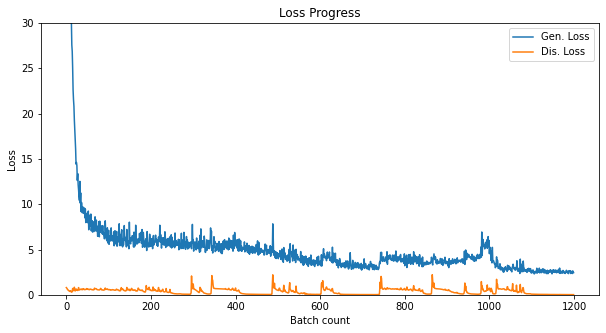

In [ ]:
# loss history
plt.figure(figsize=(10,5))
plt.title('Loss Progress')
plt.plot(loss_hist['gen'], label='Gen. Loss')
plt.plot(loss_hist['dis'], label='Dis. Loss')
plt.ylim(0,30)
plt.xlabel('Batch count')
plt.ylabel('Loss')
plt.legend()
plt.show()

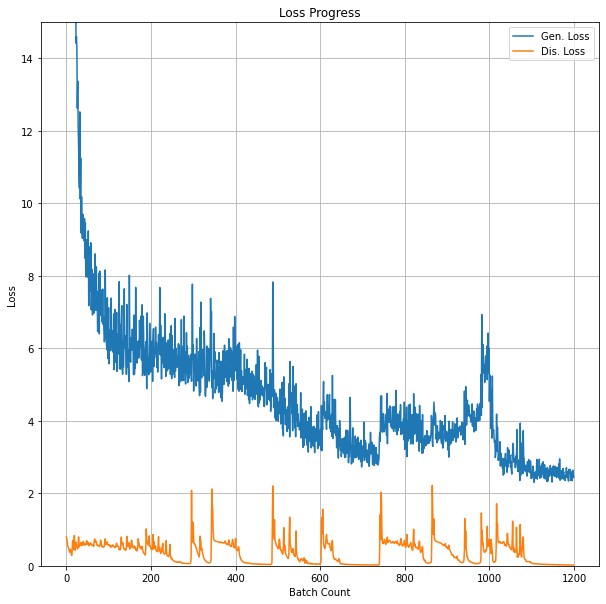

In [ ]:
# loss history
plt.figure(figsize=(10,10))
plt.title('Loss Progress')
plt.plot(loss_hist['gen'], label='Gen. Loss')
plt.plot(loss_hist['dis'], label='Dis. Loss')
plt.xlabel('Batch Count')
plt.ylabel('Loss')
plt.ylim(0,15)
plt.grid()
plt.legend(loc='upper right')
plt.show()

In [ ]:
# 가중치 저장
path2models = './models/'
os.makedirs(path2models, exist_ok=True)
path2weights_gen = os.path.join(path2models, 'weights_gen.pt')
path2weights_dis = os.path.join(path2models, 'weights_dis.pt')

torch.save(model_gen.state_dict(), path2weights_gen)
torch.save(model_dis.state_dict(), path2weights_dis)

# **테스트**

In [ ]:
!python pix2pix=pytorch/test.py --dataset facades --cuda

python3: can't open file 'test.py': [Errno 2] No such file or directory


# 생성한 가짜 이미지 확인하기

In [ ]:
# 가중치 불러오기
weights = torch.load(path2weights_gen)
model_gen.load_state_dict(weights)

<All keys matched successfully>

In [ ]:
# evaluation model
model_gen.eval()

# 가짜 이미지 생성
with torch.no_grad():
    for a,b in train_dl:
        fake_imgs = model_gen(a.to(device)).detach().cpu()
        real_imgs = b
        break

# 텐서 데이터를 PIL 이미지로 변환

In [ ]:
import shutil
shutil.rmtree('data/facades/result')
shutil.rmtree('data/facades/real')
!mkdir 'data/facades/result'
!mkdir 'data/facades/real'

In [ ]:
for i in range(32):
  transform = transforms.ToPILImage()
  img = transform((0.5*fake_imgs[i]+0.5))
  img.save("/content/data/facades/result/result_"+str(i)+".png")
  img = transform((0.5*real_imgs[i]+0.5))
  img.save("/content/data/facades/real/real_"+str(i)+".png")

# 가짜 데이터와 원본 데이터 FID 값

In [ ]:
!pip install pytorch-fid

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
!python -m pytorch_fid "/content/data/facades/result" "/content/data/facades/real"

100% 1/1 [00:01<00:00,  1.91s/it]
100% 1/1 [00:00<00:00,  3.09it/s]
FID:  144.5245514955163


# 이미지 시각화

In [ ]:
# 원본 이미지

plt.figure(figsize=(10,10))

#plt.imshow(to_pil_image(real_imgs[1]))

plt.imshow(to_pil_image(0.5*real_imgs[1]+0.5))

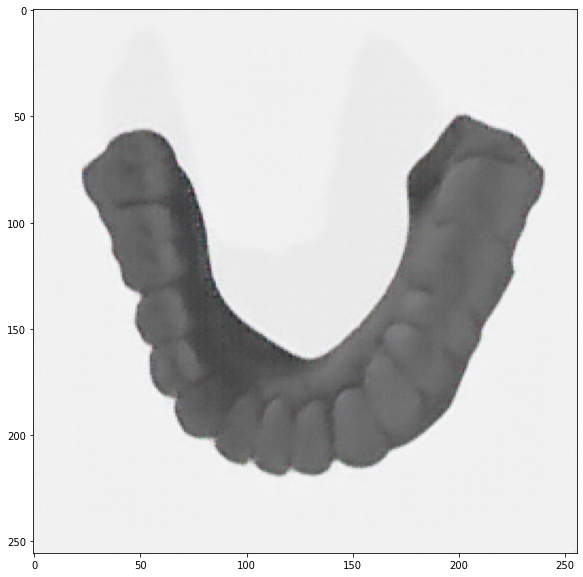

In [ ]:
# 가짜 이미지

plt.figure(figsize=(10,10))

#plt.imshow(to_pil_image(fake_imgs[1]))

plt.imshow(to_pil_image(0.5*fake_imgs[1]+0.5))
